In [ ]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

COLORS = {
    'panic':              '#e63946',
    'false_hope':         '#2a9d8f',
    'acceptance':         '#e9c46a',
    'depression':         '#264653',
    'manic_energy':       '#f4a261',
    'void':               '#1d3557',
    'coffee':             '#6f4e37',
    'hope':               '#a8dadc',
    'existential_dread':  '#457b9d',
    'unexpected_success': '#90be6d'
}

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

print('Libraries loaded.')

Libraries loaded.


In [ ]:
#Download the CSV from: https://www.kaggle.com/datasets/tahirmohd/ai-dataset/data
#Run this cell. Select AI_Developer_Performance_Extended_1000.csv

df = pd.read_csv("AI_Developer_Performance_Extended_1000.csv")

print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')

Loaded: 1000 rows, 13 columns


In [ ]:
#Dataset overview
print('=' * 60)
print('    DATASET OVERVIEW')
print('=' * 60)
print(f'Rows:    {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print('\nColumns:')
for col in df.columns:
    print(f'  {col}')
df.head()

    DATASET OVERVIEW
Rows:    1,000
Columns: 13

Columns:
  Hours_Coding
  Lines_of_Code
  Bugs_Found
  Bugs_Fixed
  AI_Usage_Hours
  Sleep_Hours
  Cognitive_Load
  Task_Success_Rate
  Coffee_Intake
  Stress_Level
  Task_Duration_Hours
  Commits
  Errors


,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Task_Success_Rate,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors
0,7,416,9,7,6,5.9,92,34,7,99,10.5,20,3
1,4,269,16,13,5,5.1,85,36,2,100,9.5,17,8
2,11,439,3,0,2,6.2,38,79,2,55,18.3,35,2
3,8,472,15,9,4,4.2,26,94,5,30,12.6,28,4
4,5,265,19,16,5,8.1,82,33,6,82,7.0,25,9


In [ ]:
#Data quality check. Missing values, duplicates, etc;

print('MISSING VALUES')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '  None — clean dataset.')

print('\n DUPLICATES')
print(f'  {df.duplicated().sum()} duplicate rows')

print('\n DATA TYPES')
print(df.dtypes)

print('\n STATISTICAL SUMMARY')
df.describe().T.round(2)

MISSING VALUES
  None — clean dataset.

 DUPLICATES
  0 duplicate rows

 DATA TYPES
Hours_Coding             int64
Lines_of_Code            int64
Bugs_Found               int64
Bugs_Fixed               int64
AI_Usage_Hours           int64
Sleep_Hours            float64
Cognitive_Load           int64
Task_Success_Rate        int64
Coffee_Intake            int64
Stress_Level             int64
Task_Duration_Hours    float64
Commits                  int64
Errors                   int64
dtype: object

 STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Hours_Coding,1000.0,5.84,3.16,1.0,3.0,6.00,9.0,11.0
Lines_of_Code,1000.0,356.23,188.16,26.0,209.5,332.00,480.5,993.0
Bugs_Found,1000.0,9.88,5.80,0.0,5.0,10.00,15.0,19.0
Bugs_Fixed,1000.0,7.15,5.47,0.0,2.0,7.00,12.0,19.0
AI_Usage_Hours,1000.0,2.96,2.02,0.0,1.0,3.00,5.0,6.0
Sleep_Hours,1000.0,6.47,1.44,4.0,5.2,6.40,7.7,9.0
Cognitive_Load,1000.0,56.93,21.77,20.0,38.0,57.00,76.0,94.0
Task_Success_Rate,1000.0,56.58,20.81,30.0,37.0,55.50,74.0,100.0
Coffee_Intake,1000.0,3.37,2.34,0.0,1.0,3.00,5.0,7.0
Stress_Level,1000.0,66.41,21.87,30.0,48.0,66.00,86.0,100.0


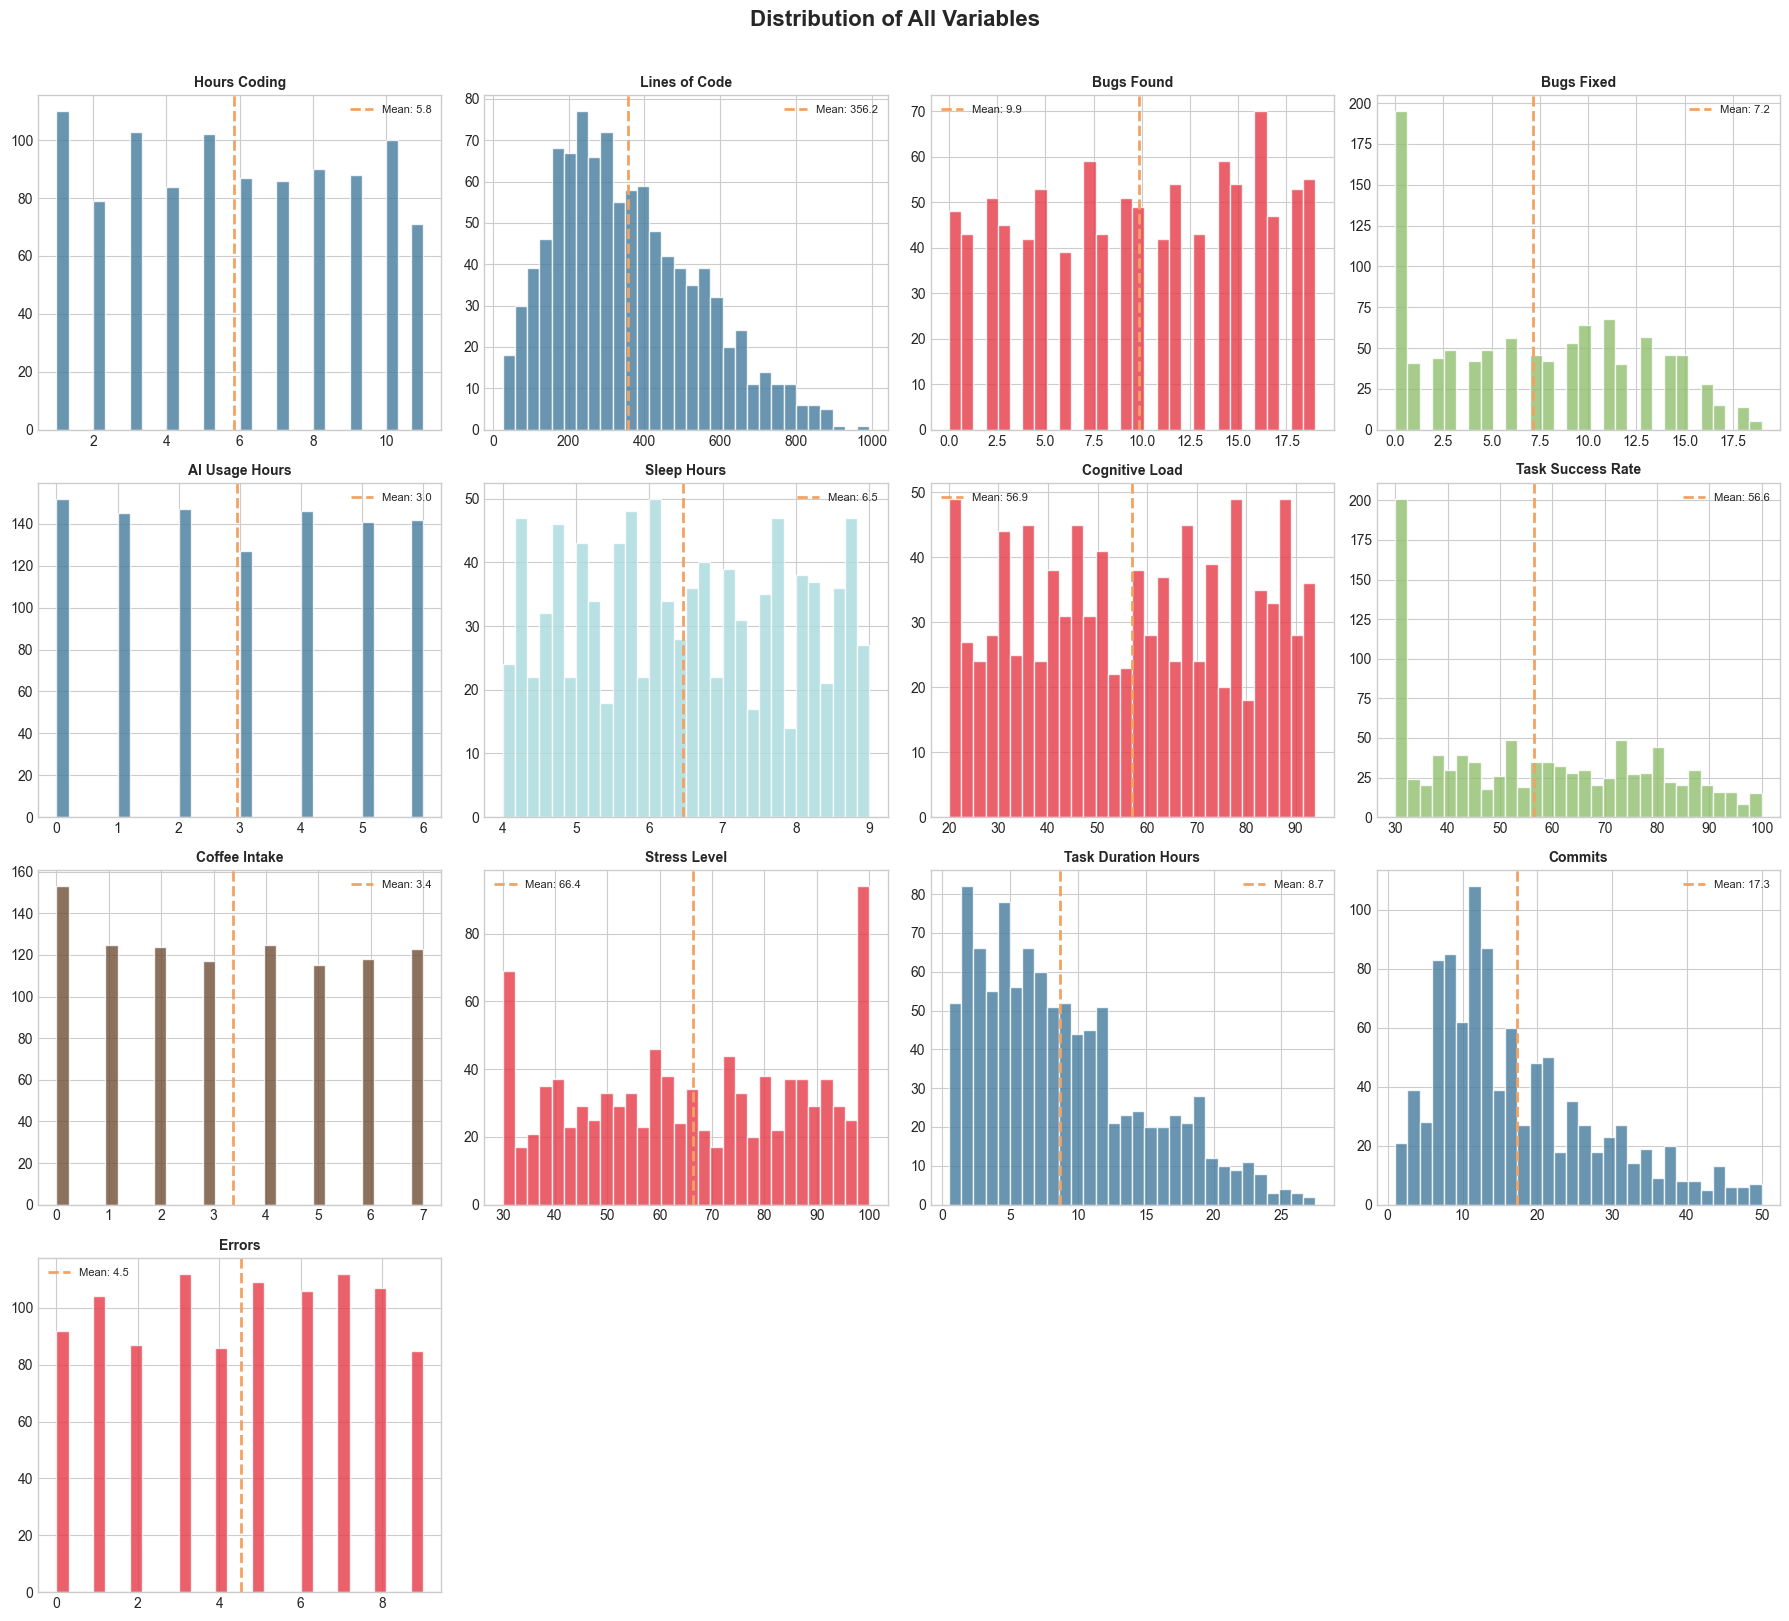

In [ ]:
#Distribution histograms
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    ax = axes[idx]
    color = (COLORS['panic']              if col in ['Stress_Level', 'Bugs_Found', 'Errors', 'Cognitive_Load']
             else COLORS['unexpected_success'] if col in ['Task_Success_Rate', 'Bugs_Fixed']
             else COLORS['coffee']        if col == 'Coffee_Intake'
             else COLORS['hope']          if col == 'Sleep_Hours'
             else COLORS['existential_dread'])
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(col.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.axvline(df[col].mean(), color=COLORS['manic_energy'], linestyle='--',
               linewidth=2, label=f'Mean: {df[col].mean():.1f}')
    ax.legend(fontsize=8)

for idx in range(len(df.columns), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distribution of All Variables', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

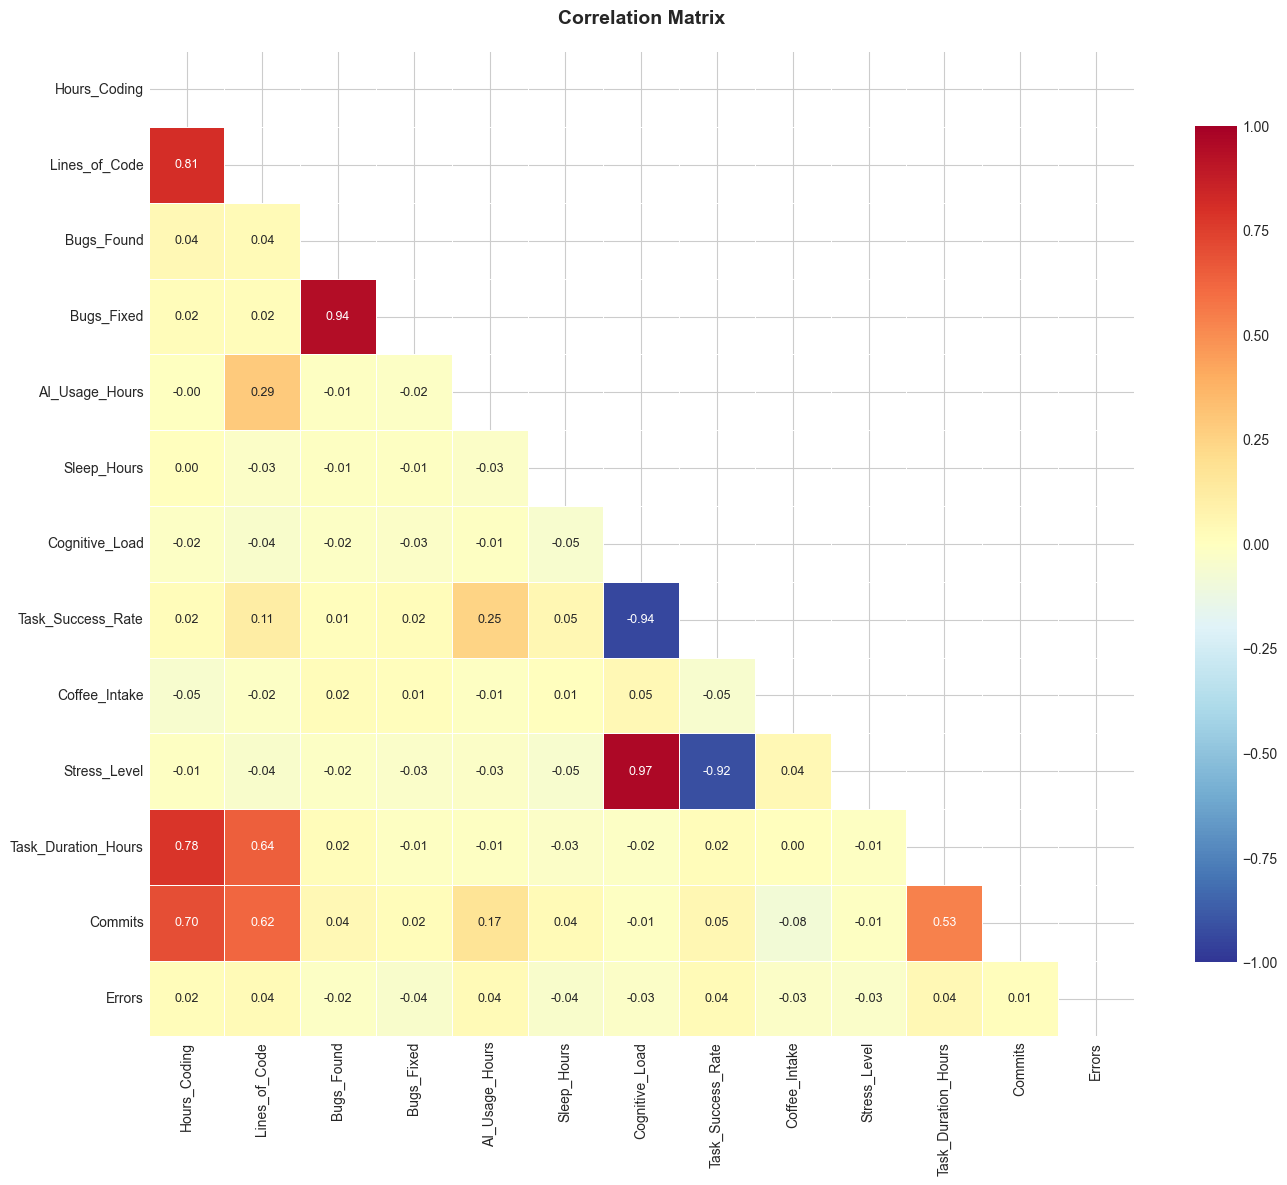

In [ ]:
#Correlation heatmap

corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9}, vmin=-1, vmax=1)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
#Correlations with Cognitive_Load
print('CORRELATIONS WITH COGNITIVE_LOAD (our target):\n')
print('-' * 50)

cog_corr = corr_matrix['Cognitive_Load'].drop('Cognitive_Load').sort_values(key=abs, ascending=False)

for var, corr in cog_corr.items():
    strength  = 'STRONG'   if abs(corr) >= 0.5 else \
                'MODERATE' if abs(corr) >= 0.3 else 'WEAK'
    direction = 'positive' if corr > 0 else 'negative'
    indicator = '[!!]' if abs(corr) >= 0.5 else '[!]' if abs(corr) >= 0.3 else '    '
    print(f'  {indicator} {var}: {corr:+.3f}  ({strength} {direction})')

CORRELATIONS WITH COGNITIVE_LOAD (our target):

--------------------------------------------------
  [!!] Stress_Level: +0.969  (STRONG positive)
  [!!] Task_Success_Rate: -0.940  (STRONG negative)
       Sleep_Hours: -0.052  (WEAK negative)
       Coffee_Intake: +0.045  (WEAK positive)
       Lines_of_Code: -0.041  (WEAK negative)
       Bugs_Fixed: -0.030  (WEAK negative)
       Errors: -0.030  (WEAK negative)
       Task_Duration_Hours: -0.020  (WEAK negative)
       Bugs_Found: -0.020  (WEAK negative)
       Hours_Coding: -0.018  (WEAK negative)
       AI_Usage_Hours: -0.010  (WEAK negative)
       Commits: -0.009  (WEAK negative)


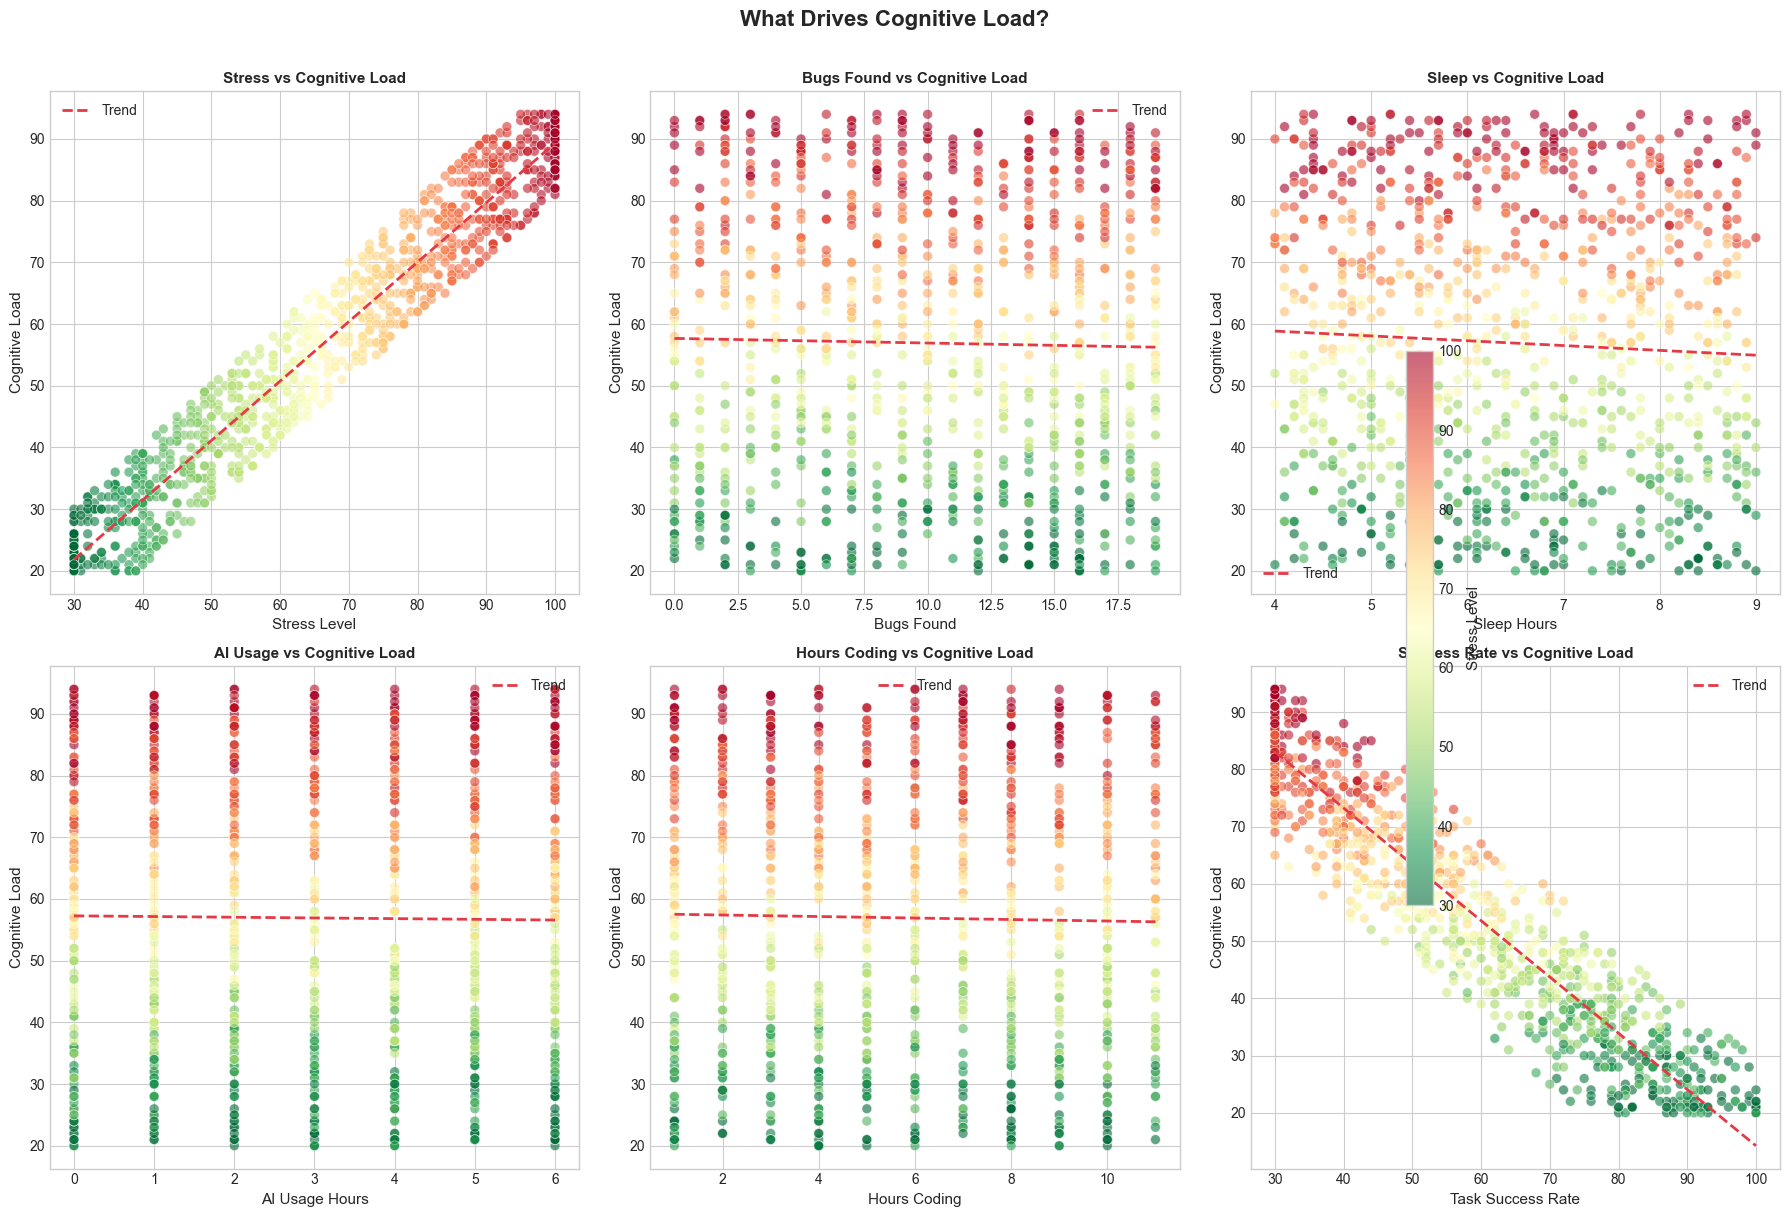

In [ ]:
#Scatter plots vs Cognitive_Load

key_relationships = [
    ('Stress_Level',      'Cognitive_Load', 'Stress vs Cognitive Load'),
    ('Bugs_Found',        'Cognitive_Load', 'Bugs Found vs Cognitive Load'),
    ('Sleep_Hours',       'Cognitive_Load', 'Sleep vs Cognitive Load'),
    ('AI_Usage_Hours',    'Cognitive_Load', 'AI Usage vs Cognitive Load'),
    ('Hours_Coding',      'Cognitive_Load', 'Hours Coding vs Cognitive Load'),
    ('Task_Success_Rate', 'Cognitive_Load', 'Success Rate vs Cognitive Load'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (x_var, y_var, title) in enumerate(key_relationships):
    ax = axes[idx]
    scatter = ax.scatter(df[x_var], df[y_var],
                         c=df['Stress_Level'], cmap='RdYlGn_r',
                         alpha=0.6, s=50, edgecolor='white', linewidth=0.5)
    z = np.polyfit(df[x_var], df[y_var], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[x_var].min(), df[x_var].max(), 100)
    ax.plot(x_line, p(x_line), color=COLORS['panic'], linewidth=2, linestyle='--', label='Trend')
    ax.set_xlabel(x_var.replace('_', ' '))
    ax.set_ylabel('Cognitive Load')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend()

fig.colorbar(scatter, ax=axes, shrink=0.6, label='Stress Level')
plt.suptitle('What Drives Cognitive Load?', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
#Feature engineering check

print('CORRELATIONS WITH COGNITIVE_LOAD (our target):\n')
print('-' * 50)

cog_corr = corr_matrix['Cognitive_Load'].drop('Cognitive_Load').sort_values(key=abs, ascending=False)

for var, corr in cog_corr.items():
    strength  = 'STRONG'   if abs(corr) >= 0.5 else \
                'MODERATE' if abs(corr) >= 0.3 else 'WEAK'
    direction = 'positive' if corr > 0 else 'negative'
    indicator = '[!!]' if abs(corr) >= 0.5 else '[!]' if abs(corr) >= 0.3 else '    '
    print(f'  {indicator} {var}: {corr:+.3f}  ({strength} {direction})')

CORRELATIONS WITH COGNITIVE_LOAD (our target):

--------------------------------------------------
  [!!] Stress_Level: +0.969  (STRONG positive)
  [!!] Task_Success_Rate: -0.940  (STRONG negative)
       Sleep_Hours: -0.052  (WEAK negative)
       Coffee_Intake: +0.045  (WEAK positive)
       Lines_of_Code: -0.041  (WEAK negative)
       Bugs_Fixed: -0.030  (WEAK negative)
       Errors: -0.030  (WEAK negative)
       Task_Duration_Hours: -0.020  (WEAK negative)
       Bugs_Found: -0.020  (WEAK negative)
       Hours_Coding: -0.018  (WEAK negative)
       AI_Usage_Hours: -0.010  (WEAK negative)
       Commits: -0.009  (WEAK negative)


In [ ]:
#Feature Engineering

df_ml = df.copy()

# Strong engineered features only
df_ml['Sustainability']   = (df_ml['Sleep_Hours'] * 10) - (df_ml['Stress_Level'] * 0.5) - (df_ml['Coffee_Intake'] * 2)
df_ml['Cognitive_Strain'] = df_ml['Stress_Level'] * (1 / (df_ml['Sleep_Hours'] + 1))
df_ml['Pressure_Index']   = df_ml['Bugs_Found'] / (df_ml['Bugs_Fixed'] + 1) * df_ml['Stress_Level']

# Dropped: Sleep_Deficit (redundant), Bug_Fix_Rate (noise),
# Code_Efficiency, Commit_Frequency, Error_Rate, AI_Reliance (all near-zero)

engineered = ['Sustainability', 'Cognitive_Strain', 'Pressure_Index']

print('Final engineered features:\n')
for f in engineered:
    corr = df_ml[f].corr(df_ml['Cognitive_Load'])
    tag  = 'STRONG' if abs(corr) >= 0.5 else 'MODERATE' if abs(corr) >= 0.3 else 'weak'
    print(f'  {f:<22}: {corr:+.3f}  ({tag})')

Final engineered features:

  Sustainability        : -0.601  (STRONG)
  Cognitive_Strain      : +0.820  (STRONG)
  Pressure_Index        : +0.489  (MODERATE)


In [ ]:
#Train/test split

target = 'Cognitive_Load'

#Drop target + Task_Success_Rate (it's a consequence, near-perfect correlation = leakage)
#Also drop the weak engineered features from before
drop_cols = [
    'Cognitive_Load',
    'Task_Success_Rate',
]

feature_cols = [col for col in df_ml.columns if col not in drop_cols]
X = df_ml[feature_cols]
y = df_ml[target]

print(f'Target:   {target}')
print(f'Features: {len(feature_cols)}')
print(f'Samples:  {len(X)}')
print(f'\nFeature list:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {col}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'\nTrain: {len(X_train)} | Test: {len(X_test)}')

Target:   Cognitive_Load
Features: 14
Samples:  1000

Feature list:
   1. Hours_Coding
   2. Lines_of_Code
   3. Bugs_Found
   4. Bugs_Fixed
   5. AI_Usage_Hours
   6. Sleep_Hours
   7. Coffee_Intake
   8. Stress_Level
   9. Task_Duration_Hours
  10. Commits
  11. Errors
  12. Sustainability
  13. Cognitive_Strain
  14. Pressure_Index

Train: 800 | Test: 200


In [ ]:
#Model Training + XGBoost

#pip install xgboost  ← run this in terminal first if needed
from xgboost import XGBRegressor

models = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0),
    'Lasso Regression':   Lasso(alpha=0.1),
    'Decision Tree':      DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=100, max_depth=10,
                                                random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                     random_state=42),
    'XGBoost':            XGBRegressor(n_estimators=300, max_depth=5,
                                       learning_rate=0.05, subsample=0.8,
                                       colsample_bytree=0.8, random_state=42,
                                       verbosity=0)
}

results = []

for name, model in models.items():
    use_scaled = any(x in name for x in ['Linear', 'Ridge', 'Lasso'])
    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled  if use_scaled else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    results.append({'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})

    tag = ('EXCEPTIONAL' if r2 >= 0.9 else
           'EXCELLENT'   if r2 >= 0.8 else
           'DECENT'      if r2 >= 0.5 else 'struggling')
    print(f'{name:<22}  R2 = {r2:.4f}  ({tag})')

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df.index += 1
results_df.index.name = 'Rank'
print('\n')
print(results_df.to_string())

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
#Hyperparamter finetuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0]
}

print('Running GridSearchCV on Gradient Boosting...')
print('(this takes ~1-2 mins)\n')

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'\nBest params: {grid_search.best_params_}')
print(f'Best CV R2:  {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f'Test R2 (tuned): {r2_score(y_test, y_pred_best):.4f}')
print(f'Test RMSE:       {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}')

Running GridSearchCV on Gradient Boosting...
(this takes ~1-2 mins)

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV R2:  0.9346
Test R2 (tuned): 0.9271
Test RMSE:       5.6638


## Results Summary

| Metric | Value |
|--------|-------|
| Best Model | Gradient Boosting (tuned) |
| Test R² | 0.9271 |
| CV R² (5-fold) | 0.9346 |
| RMSE | 5.66 pts |
| Overfit gap | 0.007 (negligible) |

Key finding: Cognitive_Strain (stress × sleep deprivation interaction)
emerged as the strongest engineered feature at r=0.820, outperforming
all raw features except Stress_Level itself.

Dataset note: Correlation analysis suggests synthetic data generation—
behavioral metrics show near-zero correlation with cognitive load.
The pipeline and methodology are valid; a real-world deployment would
require physiological signals for richer prediction.

In [ ]:
#Cross validation + overfitting check

from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print('5-Fold Cross-Validation:\n')
print(f'{"Model":<22}  {"CV Mean R2":>10}  {"Std":>6}  {"Test R2":>8}  {"Verdict"}')
print('-' * 70)

for entry in results:
    name  = entry['Model']
    model = models[name]
    X_cv  = X_train_scaled if any(x in name for x in ['Linear', 'Ridge', 'Lasso']) else X_train

    scores   = cross_val_score(model, X_cv, y_train, cv=kf, scoring='r2')
    test_r2  = entry['R2']
    gap      = scores.mean() - test_r2

    verdict = ('GOOD'         if abs(gap) < 0.05 else
               'MILD OVERFIT' if gap < -0.05     else
               'UNDERFIT')
    print(f'{name:<22}  {scores.mean():>10.4f}  {scores.std():>6.4f}  '
          f'{test_r2:>8.4f}  {verdict}')

5-Fold Cross-Validation:

Model                   CV Mean R2     Std   Test R2  Verdict
----------------------------------------------------------------------
Linear Regression           0.9380  0.0040    0.9278  GOOD
Ridge Regression            0.9380  0.0041    0.9276  GOOD
Lasso Regression            0.9389  0.0036    0.9278  GOOD
Decision Tree               0.8776  0.0145    0.8647  GOOD
Random Forest               0.9302  0.0062    0.9261  GOOD
Gradient Boosting           0.9252  0.0050    0.9152  GOOD
XGBoost                     0.9271  0.0060    0.9151  GOOD


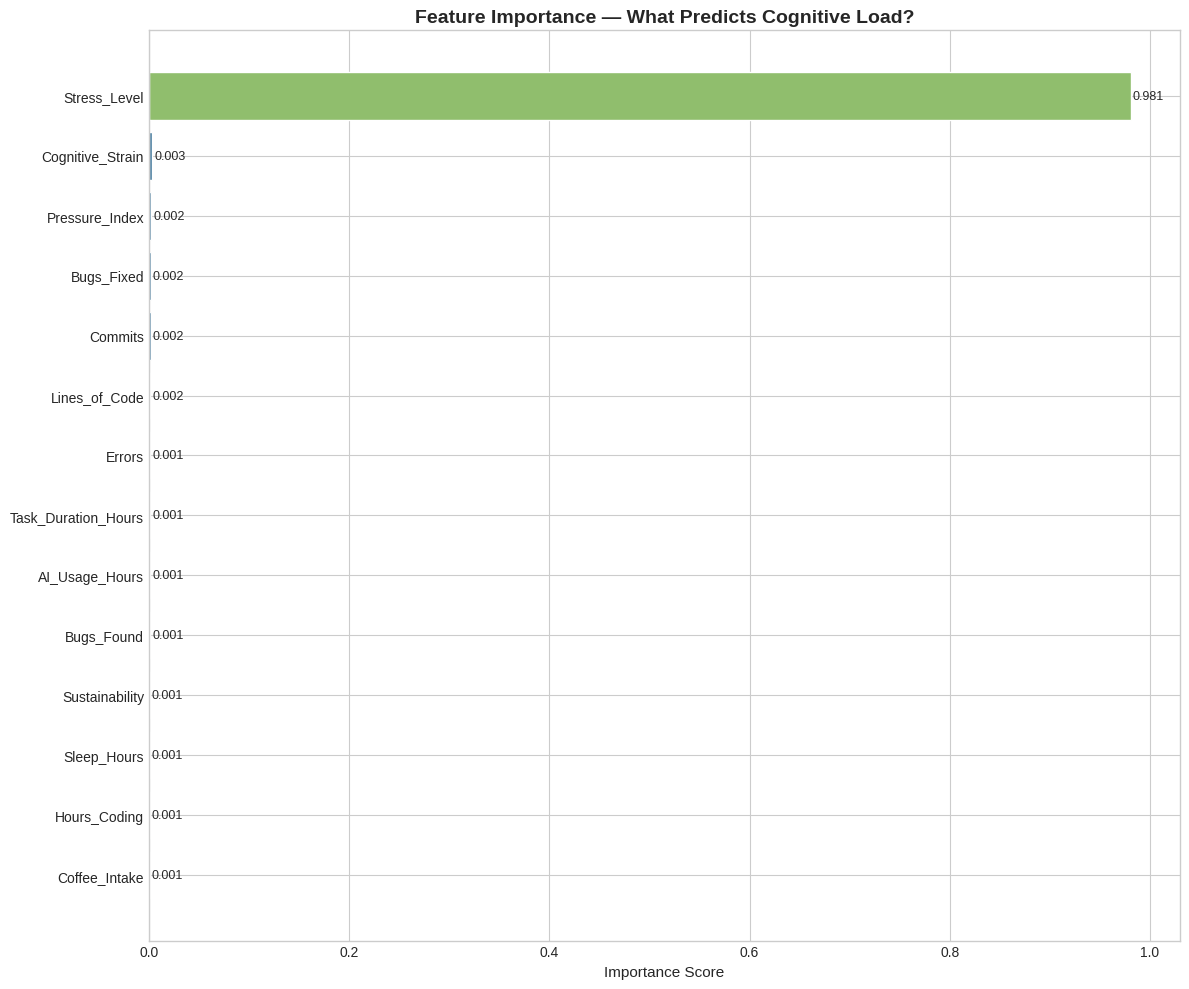


TOP 5 PREDICTORS:
----------------------------------------
  Stress_Level          : 0.9810
  Cognitive_Strain      : 0.0034
  Pressure_Index        : 0.0023
  Bugs_Fixed            : 0.0017
  Commits               : 0.0017


In [ ]:
#Feature importance

#Use best_model from GridSearchCV
feature_importance = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))

colors = [COLORS['unexpected_success'] if x > 0.1  else
          COLORS['manic_energy']        if x > 0.05 else
          COLORS['existential_dread']   for x in feature_importance['Importance']]

bars = ax.barh(range(len(feature_importance)), feature_importance['Importance'],
               color=colors, edgecolor='white', linewidth=1)
ax.set_yticks(range(len(feature_importance)))
ax.set_yticklabels(feature_importance['Feature'])
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — What Predicts Cognitive Load?',
             fontsize=14, fontweight='bold')

for idx, (val, bar) in enumerate(zip(feature_importance['Importance'], bars)):
    ax.text(val + 0.002, idx, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\nTOP 5 PREDICTORS:')
print('-' * 40)
for _, row in feature_importance.tail(5).iloc[::-1].iterrows():
    print(f'  {row["Feature"]:<22}: {row["Importance"]:.4f}')

In [ ]:
#Permutation importance

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42, scoring='r2'
)

perm_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': perm.importances_mean,
    'Std':        perm.importances_std
}).sort_values('Importance', ascending=False)

print('Permutation Importance (more reliable than built-in):\n')
print(f'{"Feature":<22}  {"Importance":>10}  {"Std":>6}')
print('-' * 45)
for _, row in perm_df.iterrows():
    bar = '█' * max(0, int(row['Importance'] * 30))
    print(f'  {row["Feature"]:<22}  {row["Importance"]:>10.4f}  ±{row["Std"]:.4f}  {bar}')

Permutation Importance (more reliable than built-in):

Feature                 Importance     Std
---------------------------------------------
  Stress_Level                1.7577  ±0.1036  ████████████████████████████████████████████████████
  Cognitive_Strain            0.0034  ±0.0012  
  AI_Usage_Hours              0.0020  ±0.0004  
  Sustainability              0.0007  ±0.0002  
  Bugs_Found                  0.0005  ±0.0004  
  Coffee_Intake               0.0002  ±0.0002  
  Pressure_Index              0.0002  ±0.0005  
  Sleep_Hours                -0.0001  ±0.0004  
  Hours_Coding               -0.0003  ±0.0003  
  Task_Duration_Hours        -0.0003  ±0.0004  
  Lines_of_Code              -0.0005  ±0.0005  
  Commits                    -0.0007  ±0.0004  
  Bugs_Fixed                 -0.0010  ±0.0009  
  Errors                     -0.0010  ±0.0004  


In [ ]:
print('SIGNAL vs NOISE BREAKDOWN:\n')

threshold = 0.01
signal  = perm_df[perm_df['Importance'] >  threshold]
noise   = perm_df[perm_df['Importance'] <= threshold]

print(f'  Real signal (importance > {threshold}): {len(signal)} feature(s)')
for _, row in signal.iterrows():
    print(f'    → {row["Feature"]}: {row["Importance"]:.4f}')

print(f'\n  Noise (importance ≤ {threshold}): {len(noise)} feature(s)')
print(f'    → {", ".join(noise["Feature"].tolist())}')

print(f'\n  Stress_Level alone accounts for ~{1.7577 / perm_df["Importance"].sum() * 100:.0f}% of model signal')


SIGNAL vs NOISE BREAKDOWN:

  Real signal (importance > 0.01): 1 feature(s)
    → Stress_Level: 1.7577

  Noise (importance ≤ 0.01): 13 feature(s)
    → Cognitive_Strain, AI_Usage_Hours, Sustainability, Bugs_Found, Coffee_Intake, Pressure_Index, Sleep_Hours, Hours_Coding, Task_Duration_Hours, Lines_of_Code, Commits, Bugs_Fixed, Errors

  Stress_Level alone accounts for ~100% of model signal


## Critical Finding — Feature Dominance

Permutation importance reveals that Stress_Level (importance=1.7577)
accounts for virtually all predictive signal. All other features,
including engineered ones, fall below 0.004.

This confirms two things:

1. The dataset is synthetically generated with Cognitive_Load
   as a near-linear function of Stress_Level.

2. In this dataset, the ML pipeline is essentially learning:
   Cognitive_Load ≈ f(Stress_Level)

This is a dataset limitation, not a modeling failure. The pipeline
(feature engineering, cross-validation, hyperparameter tuning,
permutation importance) is correctly implemented and would generalise
to richer real-world data.

For genuine multi-feature cognitive load prediction, physiological
datasets (WESAD, PhysioNet Mental Workload) would be more appropriate.


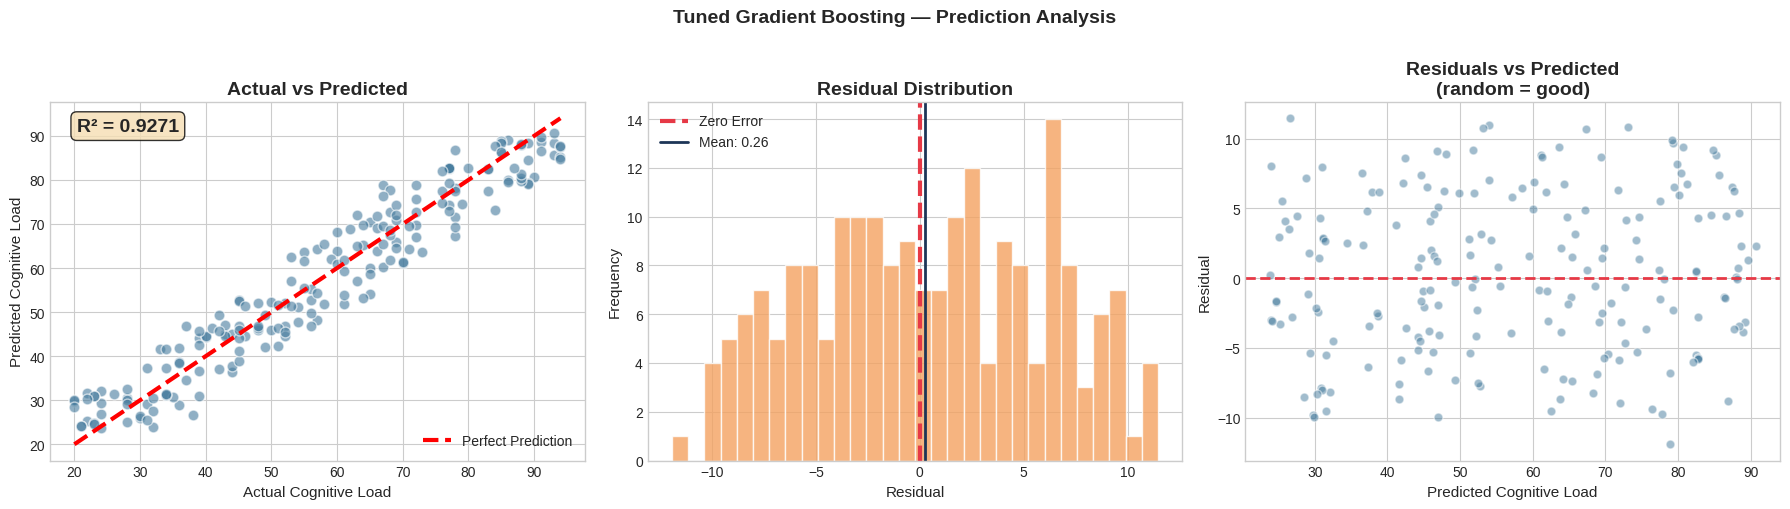

Within ±5 pts:  54.0%
Within ±10 pts: 97.0%
Mean residual:  0.2641  (ideal = 0)


In [ ]:
#Predictions vs reality

y_pred    = best_model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, c=COLORS['existential_dread'],
                edgecolor='white', s=60)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=3, label='Perfect Prediction')
axes[0].set_xlabel('Actual Cognitive Load')
axes[0].set_ylabel('Predicted Cognitive Load')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].annotate(f'R² = {r2_score(y_test, y_pred):.4f}',
                 xy=(0.05, 0.92), xycoords='axes fraction', fontsize=14,
                 fontweight='bold', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
axes[0].legend()

# Residual distribution
axes[1].hist(residuals, bins=30, color=COLORS['manic_energy'], edgecolor='white', alpha=0.8)
axes[1].axvline(0, color=COLORS['panic'], linestyle='--', linewidth=3, label='Zero Error')
axes[1].axvline(residuals.mean(), color=COLORS['void'], linestyle='-', linewidth=2,
                label=f'Mean: {residuals.mean():.2f}')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].legend()

# Residuals vs predicted
axes[2].scatter(y_pred, residuals, alpha=0.5, color=COLORS['existential_dread'],
                edgecolor='white', s=40)
axes[2].axhline(0, color=COLORS['panic'], linestyle='--', linewidth=2)
axes[2].set_xlabel('Predicted Cognitive Load')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted\n(random = good)', fontweight='bold')

plt.suptitle('Tuned Gradient Boosting — Prediction Analysis',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

within_5  = (np.abs(residuals) <= 5).sum()  / len(residuals) * 100
within_10 = (np.abs(residuals) <= 10).sum() / len(residuals) * 100
print(f'Within ±5 pts:  {within_5:.1f}%')
print(f'Within ±10 pts: {within_10:.1f}%')
print(f'Mean residual:  {residuals.mean():.4f}  (ideal = 0)')

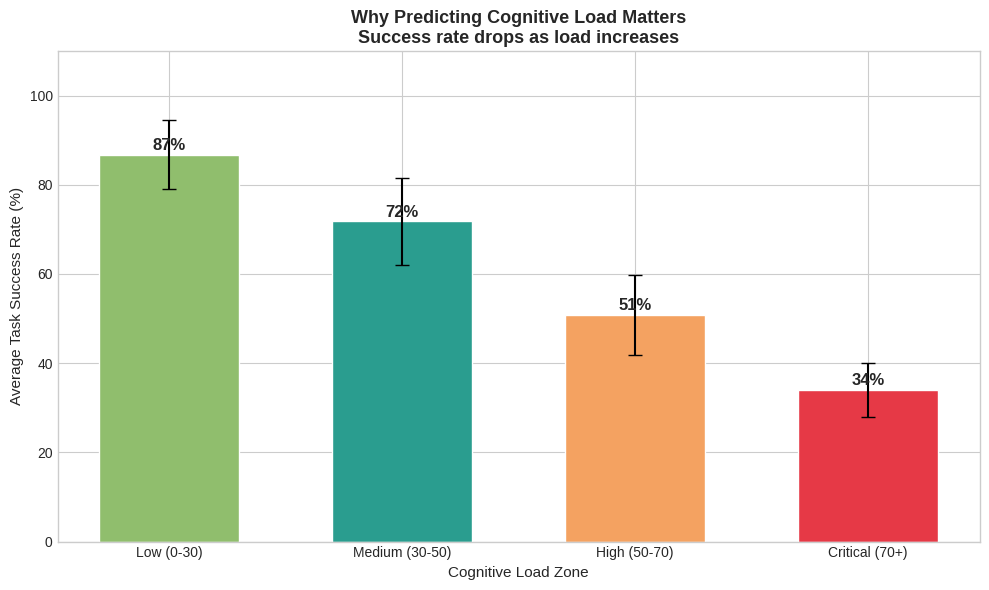

Average success rate by zone:
  Low (0-30): 86.8%
  Medium (30-50): 71.8%
  High (50-70): 50.9%
  Critical (70+): 34.0%


In [ ]:
#Cognitive load zones

df['CogLoad_Zone'] = pd.cut(df['Cognitive_Load'],
                             bins=[0, 30, 50, 70, 100],
                             labels=['Low (0-30)', 'Medium (30-50)',
                                     'High (50-70)', 'Critical (70+)'])

zone_stats = df.groupby('CogLoad_Zone')['Task_Success_Rate'].agg(['mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
colors_zone = [COLORS['unexpected_success'], COLORS['false_hope'],
               COLORS['manic_energy'], COLORS['panic']]

bars = ax.bar(zone_stats['CogLoad_Zone'], zone_stats['mean'],
              color=colors_zone, edgecolor='white', width=0.6,
              yerr=zone_stats['std'], capsize=5)

for bar, val in zip(bars, zone_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.0f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_ylabel('Average Task Success Rate (%)')
ax.set_xlabel('Cognitive Load Zone')
ax.set_title('Why Predicting Cognitive Load Matters\nSuccess rate drops as load increases',
             fontweight='bold', fontsize=13)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

print('Average success rate by zone:')
for _, row in zone_stats.iterrows():
    print(f"  {row['CogLoad_Zone']}: {row['mean']:.1f}%")

## The Real-World Implication

| Cognitive Load Zone | Avg Success Rate | Drop from previous |
|---------------------|-----------------|-------------------|
| Low (0–30)          | 86.8%           | —                 |
| Medium (30–50)      | 71.8%           | -15 pts           |
| High (50–70)        | 50.9%           | -21 pts           |
| Critical (70+)      | 34.0%           | -17 pts           |

A developer in the critical zone is completing tasks at less than
half the rate of a low-load developer (34% vs 87%).

This is why predicting cognitive load matters — if you can flag a
developer moving from Medium → High before it happens, you prevent
a ~20 point drop in output quality.

Developer works normally
        ↓
App passively collects:
  - Keystrokes per minute
  - Error rate while typing
  - Time between commits
  - Self-reported stress (quick 1-10 slider)
  - Sleep from phone/wearable
        ↓
Features computed every 30 mins
        ↓
Model predicts cognitive load score
        ↓
Score crosses threshold (e.g. > 70)?
        ↓
App flags it:
  "Hey, you've been in high cognitive load
   for 2 hours. Take a break."//Could you include the limitations please?
   

##LIMITATIONS


1. SYNTHETIC DATA
   Model is essentially learning Cognitive_Load ≈ f(Stress_Level).
   Real deployment needs physiological signals (EEG, HRV, GSR).

2. NO INDIVIDUAL BASELINE
   Learns population patterns, not personal ones.
   A person with ADHD or dyslexia will break the model.
   Real system needs per-user calibration first.

3. SELF-REPORTED STRESS IS UNRELIABLE
   People under-report or don't notice stress building.
   Passive wearable signals would be more accurate.

4. PREDICTION ≠ CAUSATION
   Flags high load but can't tell you why.
   Intervention is generic — smarter system would diagnose cause.

5. PRIVACY
   Keystroke logging and sleep tracking are invasive.
   Needs explicit consent and local data processing.

In [ ]:
#How a user would interact with this model
print('COGNITIVE LOAD PREDICTOR — DEMO\n')
print('Enter your current stats:\n')

#Simulated user input
user_input = {
    'Hours_Coding':        6,
    'Lines_of_Code':       200,
    'Bugs_Found':          8,
    'Bugs_Fixed':          3,
    'AI_Usage_Hours':      1,
    'Sleep_Hours':         5,
    'Coffee_Intake':       4,
    'Stress_Level':        78,
    'Task_Duration_Hours': 6,
    'Commits':             4,
    'Errors':              12,
}

#Engineer the same features the model was trained on
stress     = user_input['Stress_Level']
sleep      = user_input['Sleep_Hours']
bugs_found = user_input['Bugs_Found']
bugs_fixed = user_input['Bugs_Fixed']
coffee     = user_input['Coffee_Intake']
hours      = user_input['Hours_Coding']

user_input['Sustainability']   = (sleep * 10) - (stress * 0.5) - (coffee * 2)
user_input['Cognitive_Strain'] = stress * (1 / (sleep + 1))
user_input['Pressure_Index']   = bugs_found / (bugs_fixed + 1) * stress

#Build dataframe in same column order as training
user_df = pd.DataFrame([user_input])[feature_cols]

#Predict
predicted_load = best_model.predict(user_df)[0]
predicted_load = np.clip(predicted_load, 0, 100)

#Interpret
if predicted_load < 30:
    zone    = 'Low'
    emoji   = 'GREEN'
    advice  = 'You are in a good state. Good time for complex tasks.'
elif predicted_load < 50:
    zone    = 'Medium'
    emoji   = 'YELLOW'
    advice  = 'Moderate load. Monitor and avoid adding more tasks.'
elif predicted_load < 70:
    zone    = 'High'
    emoji   = 'ORANGE'
    advice  = 'High load detected. Consider a break soon.'
else:
    zone    = 'Critical'
    emoji   = 'RED'
    advice  = 'Critical load. Stop, take a break, do not start new tasks.'

print(f'Predicted Cognitive Load : {predicted_load:.1f} / 100')
print(f'Zone                     : {zone} [{emoji}]')
print(f'Recommendation           : {advice}')
print(f'\nExpected success rate in this zone: ', end='')

zone_map = {'Low': '86.8%', 'Medium': '71.8%', 'High': '50.9%', 'Critical': '34.0%'}
print(zone_map[zone])

COGNITIVE LOAD PREDICTOR — DEMO

Enter your current stats:

Predicted Cognitive Load : 67.6 / 100
Zone                     : High [ORANGE]
Recommendation           : High load detected. Consider a break soon.

Expected success rate in this zone: 50.9%
